# EDA — Layer 3: Crossings, then Determinism

Two parts, in sequence:
- **Part A — Crossings.** Cross the strong variables against each other and
  against the weak ones. Confirms which variables are redundant, and whether
  weak variables (Weather, Temperature, Landmarks, time-of-day) hide a real
  effect *inside* a road type.
- **Part B — Determinism.** The big bet: measure how little demand varies once
  we group by road attributes. If demand barely moves within a group, demand is
  nearly a lookup table — which is how a perfect score becomes possible.

Run one cell at a time. Read the note above each cell. Pause after each part and
bring results to Claude.

## Setup (same as before — run first)

In [7]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import load_config
from src.data import load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config()
train, test = load_raw(cfg)
print("train:", train.shape, " test:", test.shape)

train: (77299, 13)  test: (41778, 12)


---
# PART A — CROSSINGS

### A.1 — Are Highway / 4-5 lanes / LargeVehicles the SAME roads? (assumption A8)
**Question:** do the three strong variables describe the same physical roads?
**Look for:** in the first table, if Highways are almost all 4-5 lanes (and
Residential almost all 1-3 lanes), the variables overlap. In the second table,
same idea for LargeVehicles.
**Why it matters:** if they're redundant, we keep the most useful one and don't
treat them as independent signals.

In [8]:
print("=== Count of rows: RoadType x NumberofLanes ===")
print(pd.crosstab(train["RoadType"], train["NumberofLanes"]))

print("\n=== Count of rows: RoadType x LargeVehicles ===")
print(pd.crosstab(train["RoadType"], train["LargeVehicles"]))

print("\n=== Count of rows: NumberofLanes x LargeVehicles ===")
print(pd.crosstab(train["NumberofLanes"], train["LargeVehicles"]))

=== Count of rows: RoadType x NumberofLanes ===
NumberofLanes      1      2      3    4    5
RoadType                                    
Highway            0    855    881  915  909
Residential    23269  23091  22870    0    0
Street          3909      0      0    0    0

=== Count of rows: RoadType x LargeVehicles ===
LargeVehicles  Allowed  Not Allowed
RoadType                           
Highway           3560            0
Residential      22870        46360
Street               0         3909

=== Count of rows: NumberofLanes x LargeVehicles ===
LargeVehicles  Allowed  Not Allowed
NumberofLanes                      
1                    0        27411
2                  865        23262
3                23919            0
4                  926            0
5                  916            0


### A.2 — Mean demand for each (RoadType, NumberofLanes) combination
**Question:** does demand depend on the COMBINATION, beyond each variable alone?
**Look for:** the heatmap. Bright cells = high demand. If brightness depends on
both row and column (not just one), the combination carries information.
(Empty/grey cells = that combination doesn't occur in the data.)

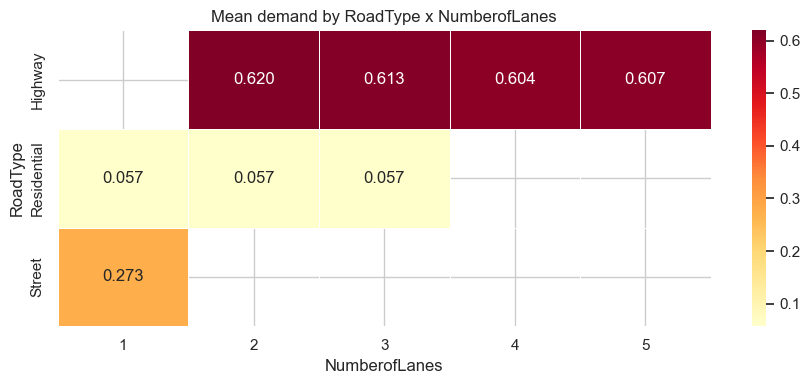

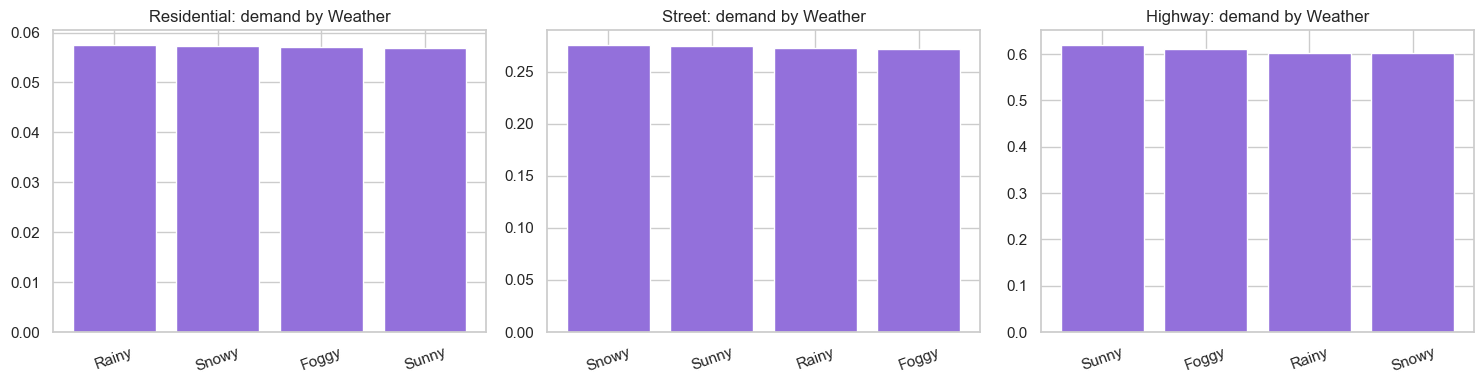

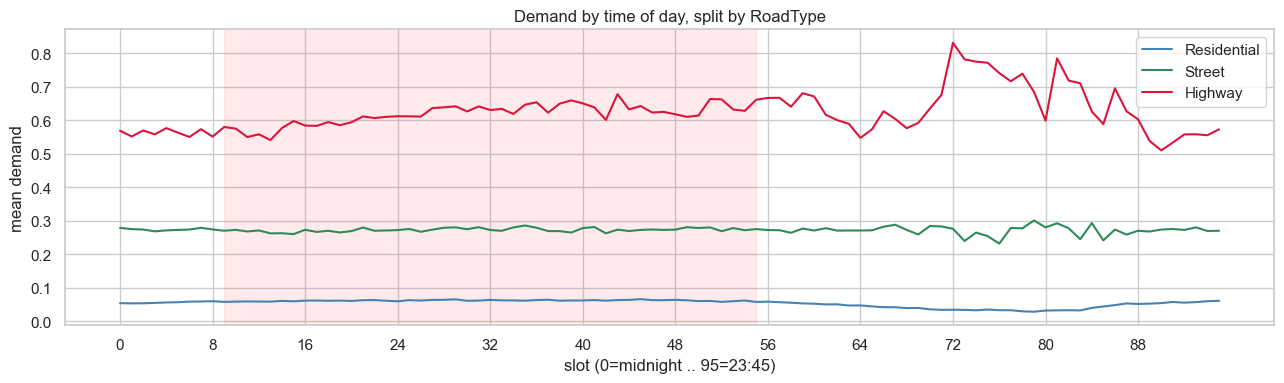

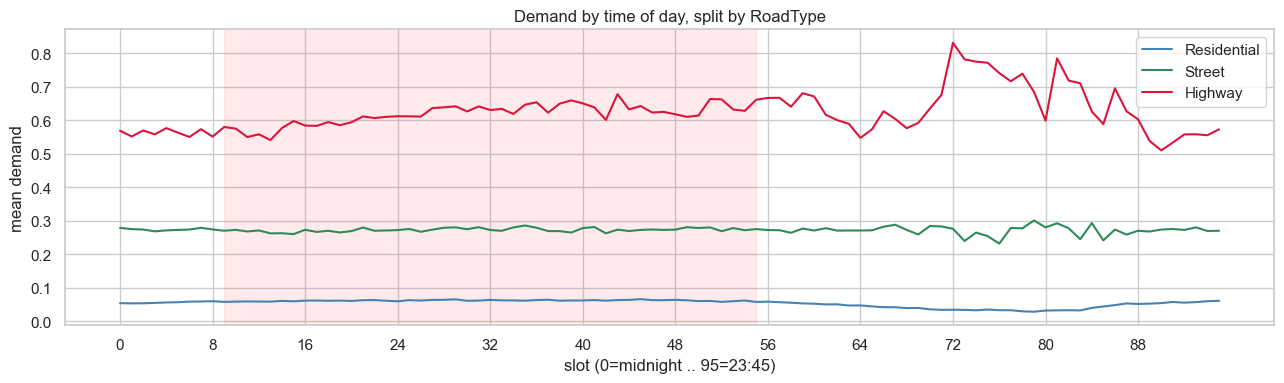

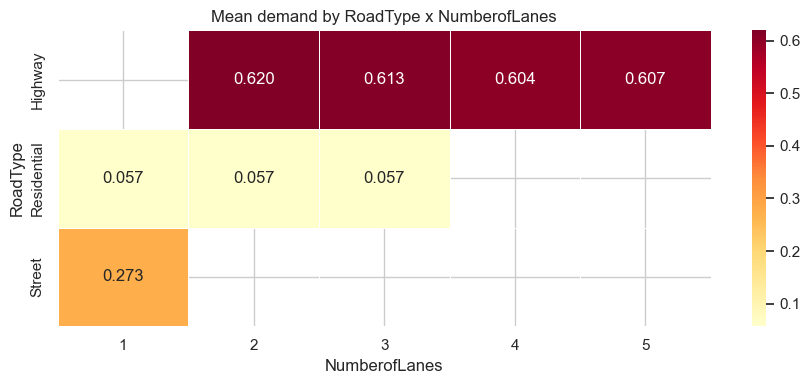

NumberofLanes         1         2         3         4         5
RoadType                                                       
Highway             NaN  0.619695  0.613320  0.603511  0.607156
Residential    0.057050  0.057326  0.057253       NaN       NaN
Street         0.273164       NaN       NaN       NaN       NaN


In [9]:
pivot = train.pivot_table(index="RoadType", columns="NumberofLanes",
                          values="demand", aggfunc="mean")
plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5)
plt.title("Mean demand by RoadType x NumberofLanes")
plt.tight_layout(); plt.show()
print(pivot)

### A.3 — Do the WEAK variables matter INSIDE a road type? (assumption A9)
**Question:** Weather looked flat overall — but is it flat inside each RoadType?
**Look for:** within each RoadType block, do the Weather bars differ? If Highway
demand changes a lot with Weather even though the overall average was flat, then
Weather DOES matter — its effect was hidden by mixing road types.

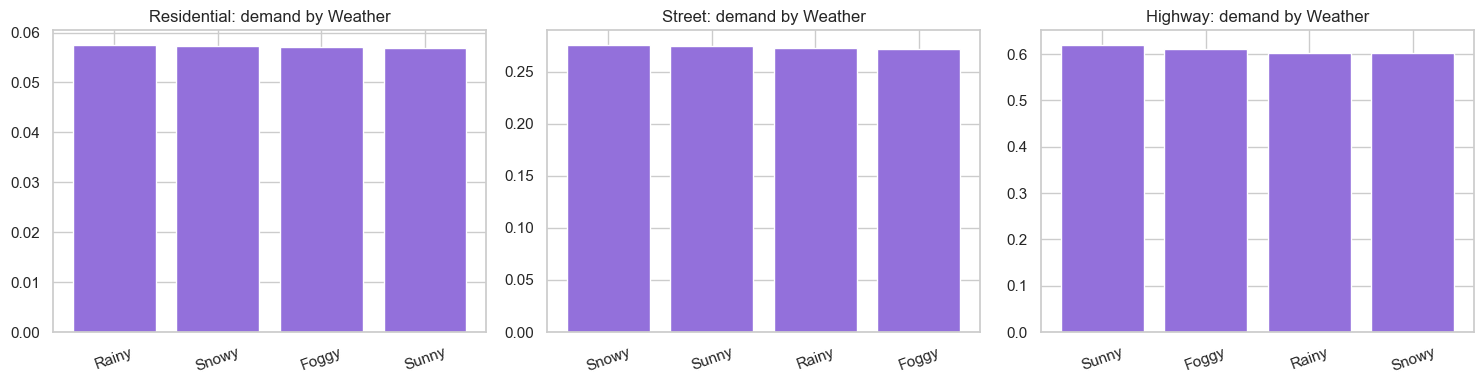

mean demand by (RoadType, Weather):
Weather         Foggy     Rainy     Snowy     Sunny
RoadType                                           
Highway      0.610843  0.602992  0.601688  0.620184
Residential  0.057165  0.057550  0.057338  0.056940
Street       0.271469  0.272577  0.275687  0.274230


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, rt in zip(axes, ["Residential", "Street", "Highway"]):
    sub = train[train["RoadType"] == rt]
    m = sub.groupby("Weather")["demand"].mean().sort_values(ascending=False)
    ax.bar(m.index, m.values, color="mediumpurple")
    ax.set_title(f"{rt}: demand by Weather")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# exact numbers
print("mean demand by (RoadType, Weather):")
print(train.groupby(["RoadType", "Weather"])["demand"].mean().unstack())

### A.4 — Does time-of-day matter inside a road type? (assumption A10)
**Question:** the daily rhythm was flat overall (90% of rows are Residential).
Do Highways or Streets have a daily pattern that got washed out?
**Look for:** three lines. If the Highway line has clear humps/dips across the
day while Residential is flat, then time-of-day matters — but only for busy roads.

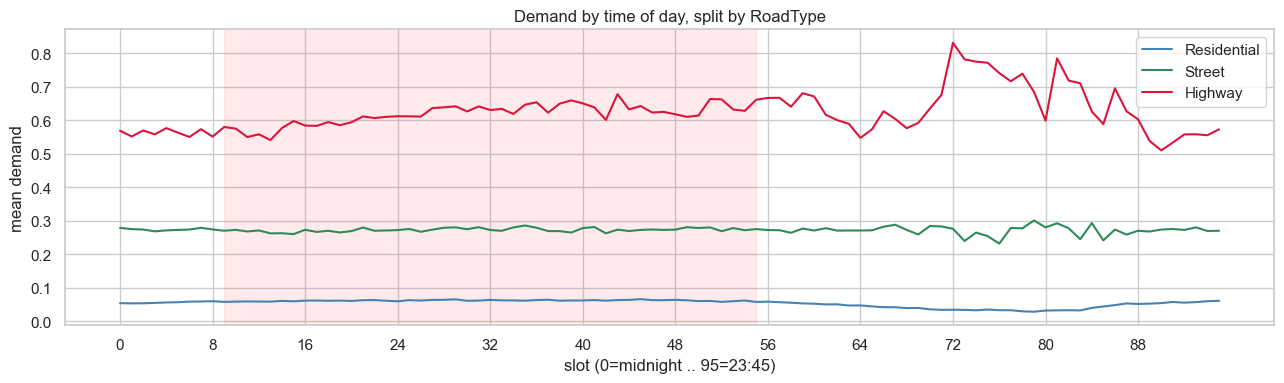

In [11]:
plt.figure(figsize=(13, 4))
for rt, color in [("Residential", "steelblue"), ("Street", "seagreen"), ("Highway", "crimson")]:
    sub = train[train["RoadType"] == rt]
    curve = sub.groupby("slot")["demand"].mean()
    plt.plot(curve.index, curve.values, label=rt, color=color)
plt.axvspan(9, 55, alpha=0.08, color="red")
plt.title("Demand by time of day, split by RoadType")
plt.xlabel("slot (0=midnight .. 95=23:45)"); plt.ylabel("mean demand")
plt.xticks(range(0, 96, 8)); plt.legend(); plt.tight_layout(); plt.show()

---
# PART B — DETERMINISM

The big question (assumption A11): given that a PERFECT score is possible,
is demand nearly DETERMINED by the visible columns? We test this by grouping
rows and measuring how much demand VARIES inside each group. Small variation
inside groups = demand is almost a lookup table from those columns.

### B.1 — How much does demand vary INSIDE groups of increasing detail?
**Question:** as we group by more columns, does demand inside each group collapse
to (almost) a single value?
**Look for:** the "mean within-group std" dropping toward 0 as we add columns.
A value near 0 means: once you know these columns, you know demand. That's the
deterministic structure we're hunting.
**Reference:** the overall std of demand is ~0.142. Any grouping that gets the
within-group std far below that is explaining a lot.

In [12]:
overall_std = train["demand"].std()
print(f"Overall demand std (no grouping): {overall_std:.4f}\n")

group_sets = [
    ["RoadType"],
    ["RoadType", "NumberofLanes"],
    ["RoadType", "NumberofLanes", "LargeVehicles"],
    ["RoadType", "NumberofLanes", "LargeVehicles", "slot"],
    ["geohash"],
    ["geohash", "slot"],
    ["geohash", "RoadType", "NumberofLanes"],
]
rows = []
for cols in group_sets:
    g = train.groupby(cols)["demand"]
    # within-group std, averaged over groups (weighted by group size)
    within_std = g.transform("std")
    mean_within = within_std.mean()
    n_groups = train.groupby(cols).ngroups
    rows.append({
        "grouping": " + ".join(cols),
        "n_groups": n_groups,
        "mean_within_group_std": round(float(mean_within), 4),
        "fraction_of_overall_std": round(float(mean_within / overall_std), 3),
    })
res = pd.DataFrame(rows)
print(res.to_string(index=False))
print("\nfraction_of_overall_std near 0  => demand is nearly determined by that grouping")

Overall demand std (no grouping): 0.1422

                                       grouping  n_groups  mean_within_group_std  fraction_of_overall_std
                                       RoadType         3                 0.0595                    0.418
                       RoadType + NumberofLanes         8                 0.0595                    0.418
       RoadType + NumberofLanes + LargeVehicles         8                 0.0595                    0.418
RoadType + NumberofLanes + LargeVehicles + slot       745                 0.0584                    0.410
                                        geohash      1249                 0.0529                    0.372
                                 geohash + slot     70876                 0.0450                    0.316
             geohash + RoadType + NumberofLanes      4276                 0.0373                    0.262

fraction_of_overall_std near 0  => demand is nearly determined by that grouping


### B.2 — Within a (geohash, slot) cell, is demand a single fixed value?
**Question:** for one location at one time-of-day, across the days we have, is
demand basically constant? (This is the cleanest "is it a lookup" test for the
seen geohashes that dominate the test set.)
**Look for:** the histogram of within-(geohash,slot) std. If it's piled up near
0, then knowing (geohash, slot) almost gives you demand — and since the test is
mostly SEEN geohashes, that's a near-direct route to the answer.

(geohash, slot) groups total: 70876
  groups with >1 observation: 6423  (only these have a std)
  median within-group std: 0.02484
  overall demand std for reference: 0.1422


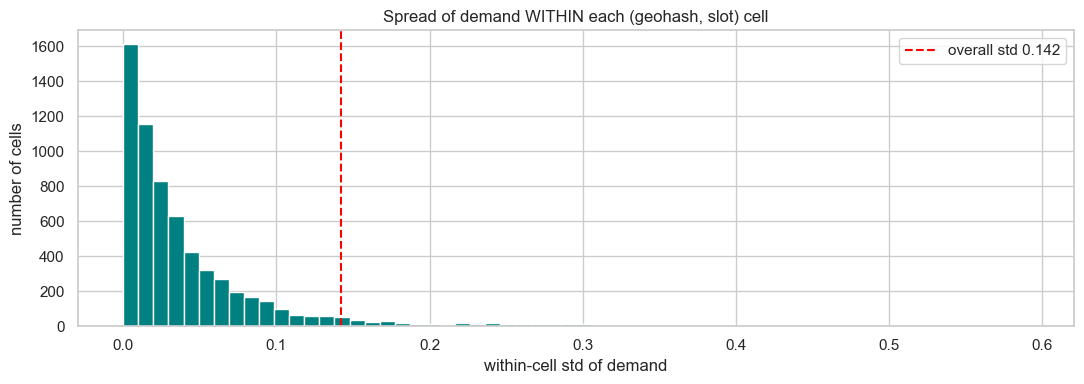

In [13]:
gs = train.groupby(["geohash", "slot"])["demand"]
gs_std = gs.std().dropna()           # std within each (geohash,slot) that has >1 row
gs_count = gs.size()
multi = gs_count[gs_count > 1]
print(f"(geohash, slot) groups total: {gs.ngroups}")
print(f"  groups with >1 observation: {len(multi)}  (only these have a std)")
print(f"  median within-group std: {gs_std.median():.5f}")
print(f"  overall demand std for reference: {overall_std:.4f}")

plt.figure(figsize=(11, 4))
plt.hist(gs_std, bins=60, color="teal")
plt.axvline(overall_std, color="red", linestyle="--", label=f"overall std {overall_std:.3f}")
plt.title("Spread of demand WITHIN each (geohash, slot) cell")
plt.xlabel("within-cell std of demand"); plt.ylabel("number of cells")
plt.legend(); plt.tight_layout(); plt.show()

### B.3 — How different is the SAME cell between day 48 and day 49?
**Question:** for cells we observe on both days (the 9 morning slots), how big is
the day-to-day change? This is assumption A13 — the per-cell day-over-day shift.
**Look for:** the histogram of (day49 - day48) for the same (geohash, slot). If
it's tightly centred on 0, the cell barely changes day to day (good for lookup).
If it's wide, the shift is large and we must model it.

Cells observed on BOTH days: 6423
  mean absolute day-to-day change: 0.06359
  median ratio day49/day48: 1.719
  correlation day48 vs day49: 0.792


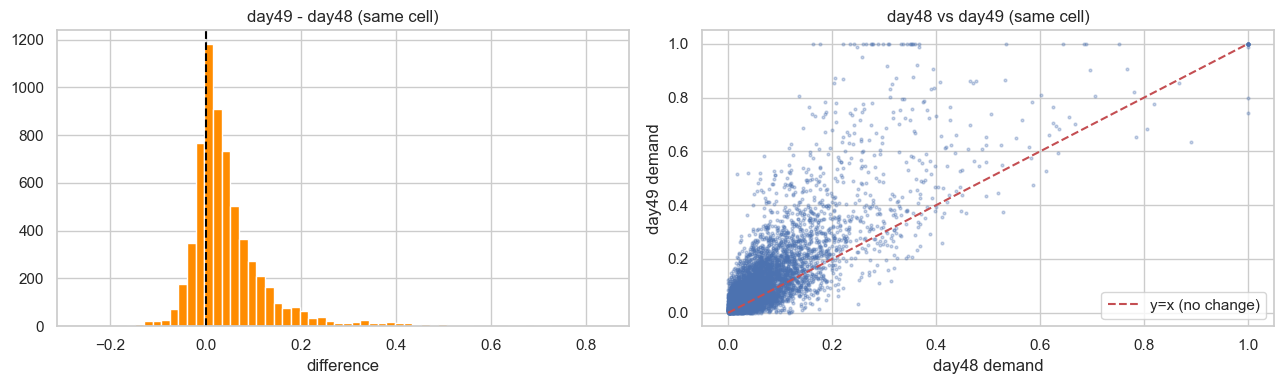

In [14]:
d48 = train[train["day"] == 48][["geohash", "slot", "demand"]].rename(columns={"demand": "d48"})
d49 = train[train["day"] == 49][["geohash", "slot", "demand"]].rename(columns={"demand": "d49"})
both = d49.merge(d48, on=["geohash", "slot"], how="inner")
both["diff"] = both["d49"] - both["d48"]
both["ratio"] = both["d49"] / both["d48"].replace(0, np.nan)

print(f"Cells observed on BOTH days: {len(both)}")
print(f"  mean absolute day-to-day change: {both['diff'].abs().mean():.5f}")
print(f"  median ratio day49/day48: {both['ratio'].median():.3f}")
print(f"  correlation day48 vs day49: {both['d48'].corr(both['d49']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(both["diff"], bins=60, color="darkorange")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("day49 - day48 (same cell)"); axes[0].set_xlabel("difference")
axes[1].scatter(both["d48"], both["d49"], s=4, alpha=0.3)
lims = [0, both[["d48", "d49"]].max().max()]
axes[1].plot(lims, lims, "r--", label="y=x (no change)")
axes[1].set_title("day48 vs day49 (same cell)")
axes[1].set_xlabel("day48 demand"); axes[1].set_ylabel("day49 demand"); axes[1].legend()
plt.tight_layout(); plt.show()

---
## End of Layer 3

Bring to Claude:
- PART A: which variables are redundant? do any weak variables come alive inside
  a road type? does time-of-day matter for busy roads?
- PART B: how low did the within-group std go (B.1)? are (geohash,slot) cells
  nearly constant (B.2)? how big is the day-to-day shift (B.3)?
Together these decide whether we model demand as a near-lookup or as a learned
function, and what features to build.